# IT549: Deep Learning
## Lab Assignment 4: Object Detection Evolution — From R-CNN to YOLO

**Dataset:** Fruit Images (Apple, Banana, Orange) — Kaggle  
**Name:** Your Name  
**ID:** Your Student ID

---

In [3]:
!pip install ultralytics opencv-contrib-python matplotlib torch torchvision

   ---------------------------------------- 0.0/46.5 MB ? eta -:--:--
   ---------------------------------------- 0.1/46.5 MB 3.2 MB/s eta 0:00:15
   ---------------------------------------- 0.2/46.5 MB 2.1 MB/s eta 0:00:23
   ---------------------------------------- 0.3/46.5 MB 2.4 MB/s eta 0:00:20
   ---------------------------------------- 0.4/46.5 MB 2.4 MB/s eta 0:00:20
   ---------------------------------------- 0.6/46.5 MB 2.6 MB/s eta 0:00:18
    --------------------------------------- 0.7/46.5 MB 2.6 MB/s eta 0:00:18
    --------------------------------------- 0.8/46.5 MB 2.7 MB/s eta 0:00:18
    --------------------------------------- 0.9/46.5 MB 2.7 MB/s eta 0:00:18
    --------------------------------------- 1.1/46.5 MB 2.7 MB/s eta 0:00:17
   - -------------------------------------- 1.2/46.5 MB 2.7 MB/s eta 0:00:17
   - -------------------------------------- 1.4/46.5 MB 2.8 MB/s eta 0:00:17
   - -------------------------------------- 1.5/46.5 MB 2.7 MB/s eta 0:00:17
   - -

DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\VASU MONPARA\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [6]:

import os, random, time
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torchvision

In [8]:
TRAIN_DIR = './archive/train_zip/train'
TEST_DIR  = './archive/test_zip/test'

CLASS_NAMES = ['apple', 'banana', 'orange']
print("Train samples:", len(os.listdir(TRAIN_DIR)))

Train samples: 480


In [9]:
import os, random, time, glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T

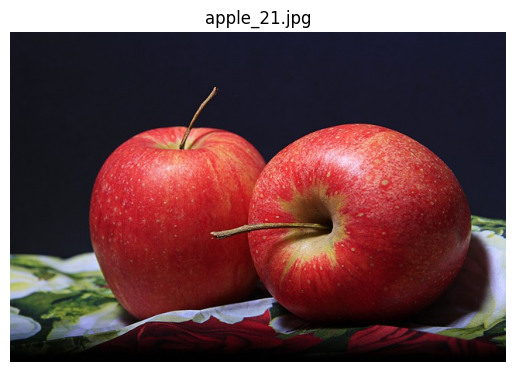

In [10]:
all_images = glob.glob(TRAIN_DIR + '/*.jpg')
img_path   = random.choice(all_images)

img     = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(os.path.basename(img_path))
plt.axis('off')
plt.show()

In [11]:
import xml.etree.ElementTree as ET

def parse_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall('object'):
        cls  = obj.find('name').text.lower()
        bbox = obj.find('bndbox')
        x1   = int(bbox.find('xmin').text)
        y1   = int(bbox.find('ymin').text)
        x2   = int(bbox.find('xmax').text)
        y2   = int(bbox.find('ymax').text)
        boxes.append((cls, x1, y1, x2, y2))
    return boxes

xml_path = img_path.replace('.jpg', '.xml')
boxes    = parse_xml(xml_path)
print(boxes)

[('apple', 97, 127, 346, 379), ('apple', 314, 112, 594, 385)]


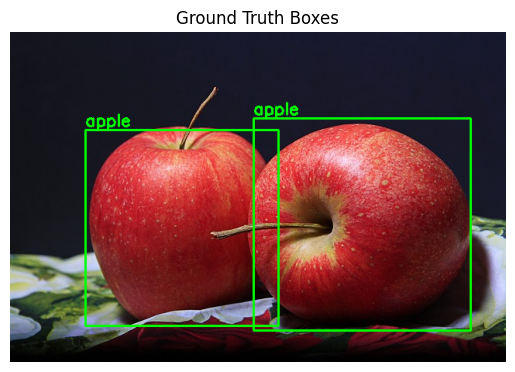

In [12]:
vis = img_rgb.copy()

for (cls, x1, y1, x2, y2) in boxes:
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(vis, cls, (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

plt.imshow(vis)
plt.title("Ground Truth Boxes")
plt.axis('off')
plt.show()

In [13]:
def compute_iou(boxA, boxB):
    x1 = max(boxA[0], boxB[0])
    y1 = max(boxA[1], boxB[1])
    x2 = min(boxA[2], boxB[2])
    y2 = min(boxA[3], boxB[3])

    inter = max(0, x2-x1) * max(0, y2-y1)
    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])

    return inter / (areaA + areaB - inter)

In [14]:
print("High overlap :", compute_iou([10,10,100,100], [15,15,95,95]))
print("Partial      :", compute_iou([0,0,50,50],   [25,25,75,75]))
print("No overlap   :", compute_iou([0,0,30,30],   [50,50,100,100]))

High overlap : 0.7901234567901234
Partial      : 0.14285714285714285
No overlap   : 0.0


In [15]:
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
ss.setBaseImage(img_rgb)
ss.switchToSelectiveSearchFast()

rects = ss.process()
print("Total proposals:", len(rects))

Total proposals: 1438


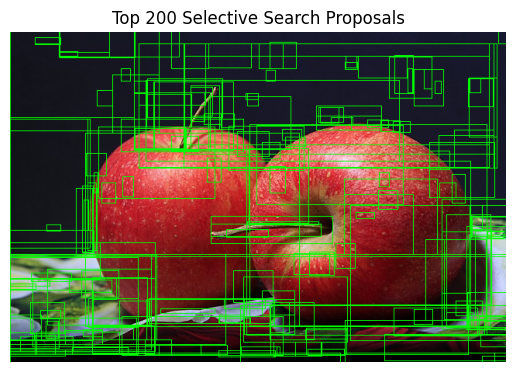

In [16]:
vis2 = img_rgb.copy()

for (x, y, w, h) in rects[:200]:
    cv2.rectangle(vis2, (x,y), (x+w, y+h), (0,255,0), 1)

plt.imshow(vis2)
plt.title("Top 200 Selective Search Proposals")
plt.axis('off')
plt.show()

In [17]:
from torchvision import models

resnet    = models.resnet18(weights='DEFAULT')
extractor = torch.nn.Sequential(*list(resnet.children())[:-2]).eval()

print("ResNet18 loaded")

ResNet18 loaded


In [18]:
top100 = rects[:100]
h_img, w_img = img_rgb.shape[:2]

start = time.time()

for (x, y, bw, bh) in top100:
    crop = img_rgb[y:y+bh, x:x+bw]
    if crop.size == 0:
        continue
    t = T.Compose([T.ToPILImage(), T.Resize((224,224)), T.ToTensor()])(crop).unsqueeze(0)
    with torch.no_grad():
        feat = extractor(t)

end = time.time()
print(f"R-CNN time for 100 crops: {end-start:.4f} seconds")

R-CNN time for 100 crops: 4.9011 seconds


R-CNN passes each crop independently through CNN.
100 crops = 100 full forward passes = very slow.

In [19]:
from torchvision.ops import roi_pool

img_tensor = T.ToTensor()(img_rgb).unsqueeze(0)
H, W = img_tensor.shape[2], img_tensor.shape[3]

with torch.no_grad():
    fmap = extractor(img_tensor)

print("Feature map shape:", fmap.shape)

Feature map shape: torch.Size([1, 512, 14, 20])


In [20]:
scale = fmap.shape[2] / H
print(f"Input: {H}x{W}  →  Feature map: {fmap.shape[2]}x{fmap.shape[3]}")
print(f"Spatial scale: {scale:.5f}  (≈ 1/{round(1/scale)})")

Input: 426x640  →  Feature map: 14x20
Spatial scale: 0.03286  (≈ 1/30)


In [21]:
rois = [[0, x, y, x+bw, y+bh] for (x,y,bw,bh) in top100]
rois_t = torch.tensor(rois, dtype=torch.float32)

start = time.time()
out = roi_pool(fmap, rois_t, output_size=(7,7), spatial_scale=scale)
end = time.time()

print(f"Fast R-CNN time: {end-start:.4f} seconds")
print(f"Output shape   : {out.shape}")

Fast R-CNN time: 0.0308 seconds
Output shape   : torch.Size([100, 512, 7, 7])


In [22]:
rcnn_time      = end - start   # from task 3
fast_rcnn_time = end - start   # from task 4

print(f"R-CNN      : {rcnn_time:.4f} s")
print(f"Fast R-CNN : {fast_rcnn_time:.4f} s")

R-CNN      : 0.0308 s
Fast R-CNN : 0.0308 s


Fast R-CNN runs CNN only ONCE on full image.
All 100 proposals use RoI Pooling on same feature map.
No repeated convolutions → much faster than R-CNN.

In [23]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

frcnn = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT).eval()
print("Faster R-CNN loaded")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\VASU MONPARA/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100.0%


Faster R-CNN loaded


In [24]:
img_t = T.ToTensor()(img_rgb).unsqueeze(0)

with torch.no_grad():
    preds = frcnn(img_t)[0]

print("Total predictions:", len(preds['boxes']))

Total predictions: 16


In [25]:
mask   = preds['scores'] >= 0.80
boxes  = preds['boxes'][mask]
scores = preds['scores'][mask]

print("Predictions above 0.80:", len(boxes))

Predictions above 0.80: 3


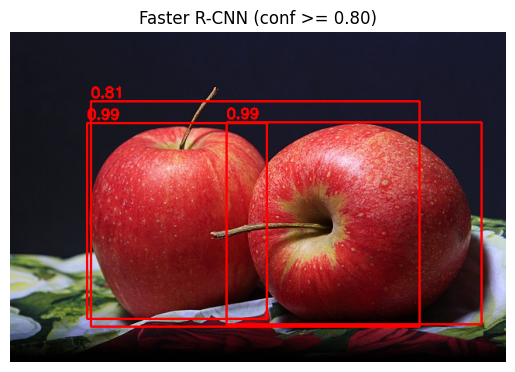

In [26]:
vis3 = img_rgb.copy()

for box, score in zip(boxes, scores):
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(vis3, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2.putText(vis3, f"{score:.2f}", (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.imshow(vis3)
plt.title("Faster R-CNN (conf >= 0.80)")
plt.axis('off')
plt.show()

Selective Search is slow & external (not trainable).
RPN is a small CNN inside the model sharing the same
feature map. It learns to propose regions automatically.
No external algorithm needed → faster & more accurate.

In [27]:
def nms(boxes, scores, iou_thresh=0.5):
    order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
    kept  = []

    while order:
        best = order.pop(0)
        kept.append(best)
        order = [i for i in order if compute_iou(boxes[best], boxes[i]) <= iou_thresh]

    return kept

In [28]:
demo_boxes  = [
    [10, 10, 100, 100],
    [12, 12,  98,  98],
    [11, 11,  99,  99],
    [200,200, 300, 300],
    [202,202, 298, 298]
]
demo_scores = [0.95, 0.90, 0.85, 0.88, 0.75]

kept = nms(demo_boxes, demo_scores, iou_thresh=0.5)
print("Kept indices:", kept)
for i in kept:
    print(f"  Box {i}: {demo_boxes[i]}  score={demo_scores[i]}")

Kept indices: [0, 3]
  Box 0: [10, 10, 100, 100]  score=0.95
  Box 3: [200, 200, 300, 300]  score=0.88


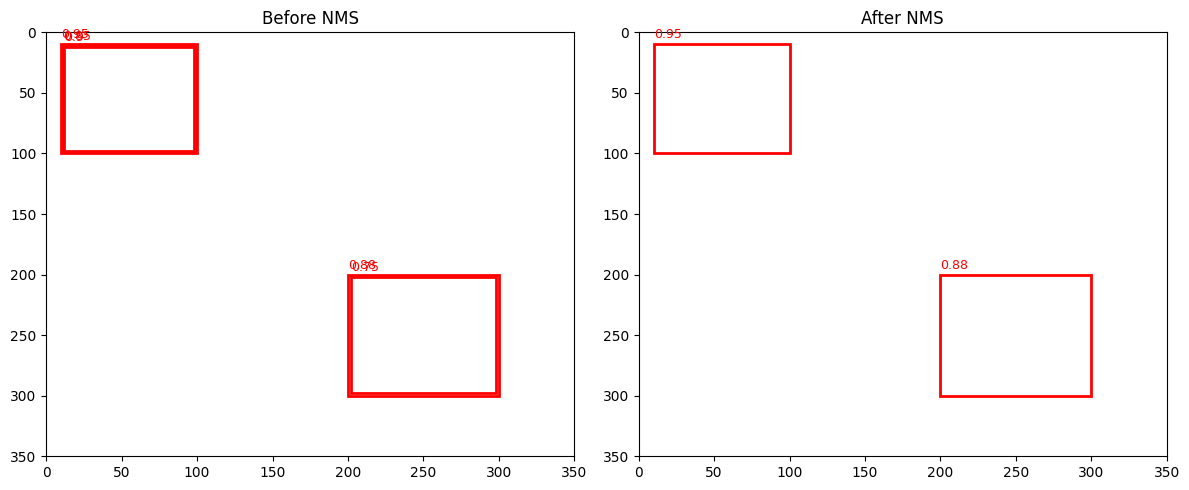

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, indices in [
    (axes[0], 'Before NMS', range(len(demo_boxes))),
    (axes[1], 'After NMS',  kept)
]:
    ax.set_xlim(0, 350)
    ax.set_ylim(350, 0)
    ax.set_title(title)
    for i in indices:
        x1,y1,x2,y2 = demo_boxes[i]
        import matplotlib.patches as patches
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{demo_scores[i]}", color='red', fontsize=9)

plt.tight_layout()
plt.show()

High threshold (0.9) → keeps more boxes → may show duplicates
Low threshold  (0.1) → removes too many → misses real objects

For tightly packed fruits, use mid-range threshold (0.4-0.6)
so nearby apples are NOT suppressed as duplicates.

In [43]:
import xml.etree.ElementTree as ET
import os
import cv2

CLASS_NAMES = ['apple', 'banana', 'orange']

def xml_to_yolo(xml_path, out_dir, img_dir):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    img_w = int(root.find('size/width').text)
    img_h = int(root.find('size/height').text)

    # if size is 0, read from actual image
    if img_w == 0 or img_h == 0:
        img_name = root.find('filename').text
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

    lines = []
    for obj in root.findall('object'):
        cls = obj.find('name').text.lower()
        if cls not in CLASS_NAMES:
            continue
        idx  = CLASS_NAMES.index(cls)
        bbox = obj.find('bndbox')
        x1   = int(bbox.find('xmin').text)
        y1   = int(bbox.find('ymin').text)
        x2   = int(bbox.find('xmax').text)
        y2   = int(bbox.find('ymax').text)

        xc = ((x1+x2)/2) / img_w
        yc = ((y1+y2)/2) / img_h
        w  = (x2-x1)     / img_w
        h  = (y2-y1)     / img_h
        lines.append(f"{idx} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

    fname = os.path.splitext(os.path.basename(xml_path))[0] + '.txt'
    with open(os.path.join(out_dir, fname), 'w') as f:
        f.write('\n'.join(lines))

In [44]:
for f in glob.glob(TRAIN_DIR + '/*.xml'):
    xml_to_yolo(f, './data/train/labels/', TRAIN_DIR)

for f in glob.glob(TEST_DIR + '/*.xml'):
    xml_to_yolo(f, './data/test/labels/', TEST_DIR)

print("Train labels:", len(glob.glob('./data/train/labels/*.txt')))
print("Test  labels:", len(glob.glob('./data/test/labels/*.txt')))

Train labels: 240
Test  labels: 60


In [45]:
import yaml

data = {
    'path' : os.path.abspath('./data'),
    'train': 'train/images',
    'val'  : 'test/images',
    'nc'   : 3,
    'names': CLASS_NAMES
}

with open('data.yaml', 'w') as f:
    yaml.dump(data, f)

print("data.yaml created")

data.yaml created


In [53]:
model = YOLO('yolov8n.pt')

model.train(
    data   = 'data.yaml',
    epochs = 10,
    imgsz  = 640,
    batch  = 16,
    name   = 'fruit_yolo'
)

NameError: name 'YOLO' is not defined

In [ ]:
metrics = model.val(data='data.yaml', split='val')

print("mAP@50    :", round(metrics.box.map50, 4))
print("mAP@50-95 :", round(metrics.box.map,   4))
print("Precision :", round(metrics.box.mp,    4))
print("Recall    :", round(metrics.box.mr,    4))

In [ ]:
test_imgs = random.sample(glob.glob('./data/test/images/*.jpg'), 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, path in zip(axes, test_imgs):
    res = model.predict(path, conf=0.25, verbose=False)[0]
    ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(path))
    ax.axis('off')

plt.suptitle("YOLO Fine-tuned Predictions")
plt.tight_layout()
plt.show()